# Spatial Analysis

## Environmental Degradation and Well-being Analysis

### Objectives:
1. Analyze geographic patterns in environmental indicators
2. Identify spatial clusters and hotspots
3. Test for spatial autocorrelation
4. Build geographically weighted regression models
5. Create interactive maps and visualizations
6. Compare environmental performance across regions

### Key Questions:
- How do environmental indicators vary geographically?
- Are there spatial clusters of high or low environmental impact?
- Do neighboring regions influence each other?
- How do relationships between activities and outcomes vary by location?
- Which regions are leaders in environmental well-being?

In [2]:
# Install required packages
import subprocess
import sys

def install_if_needed(package):
    try:
        __import__(package)
        print(f"{package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
        print(f"{package} installed successfully")

# Install geopandas (includes dependencies)
install_if_needed('geopandas')

# Install geodatasets for easy access to geographic data
install_if_needed('geodatasets')

print("\nAll geographic packages ready!")


In [3]:
%pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium import plugins
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load and Prepare Geographic Data

In [6]:
# Load the processed dataset with geographic information
df = pd.read_csv('../data/processed/master_dataset.csv')

print(f"Dataset loaded: {df.shape}")
print(f"Years available: {df['year'].min()} - {df['year'].max()}")

# Use most recent year with good data coverage (2020)
df_recent = df[df['year'] == 2020].copy()
print(f"\nData for 2020: {len(df_recent)} countries/regions")

# Load world shapefile for mapping
print("\nLoading world boundaries...")

try:
    # Use geodatasets package (modern replacement for gpd.datasets)
    import geodatasets
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

    # Alternative: Load directly from Natural Earth
    if len(world) < 50:  # If naturalearth.land doesn't have countries, try countries dataset
        url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
        world = gpd.read_file(url)

except Exception as e:
    print(f"Trying direct URL: {e}")
    # Fallback: Load directly from Natural Earth Data
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

print(f"World shapefile loaded: {len(world)} geometries")

# Clean country names for better matching
name_mapping = {
    'United States of America': 'United States',
    'Russian Federation': 'Russia',
    'Republic of Korea': 'Korea, Rep.',
    'Dem. Rep. Congo': 'Congo, Dem. Rep.',
    'Central African Rep.': 'Central African Republic',
    'S. Sudan': 'South Sudan',
    'Dominican Rep.': 'Dominican Republic',
    'Eq. Guinea': 'Equatorial Guinea',
    'Bosnia and Herz.': 'Bosnia and Herzegovina',
    'Solomon Is.': 'Solomon Islands',
    'Czechia': 'Czech Republic',
    'eSwatini': 'Eswatini'
}

# Handle different column name conventions
if 'NAME' in world.columns:
    world['name'] = world['NAME']
elif 'ADMIN' in world.columns:
    world['name'] = world['ADMIN']
elif 'name' not in world.columns:
    world['name'] = world.iloc[:, 0]  # Use first column if no standard name column

world['name_clean'] = world['name'].replace(name_mapping)

# Merge data with geographic boundaries
gdf = world.merge(df_recent, left_on='name_clean', right_on='country_name', how='left')
print(f"\nMerged geodataframe: {len(gdf)} rows")
print(f"Countries with data: {gdf['country_name'].notna().sum()}")

# Add continent information
if 'CONTINENT' in gdf.columns:
    gdf['continent'] = gdf['CONTINENT']
elif 'continent' not in gdf.columns:
    # Assign continents manually if not available
    gdf['continent'] = 'Unknown'

gdf['region'] = gdf['continent']

print("\nGeographic data prepared successfully")
print(f"\nAvailable indicators for mapping:")
indicators = ['pm25_air_pollution', 'energy_use_per_capita', 'forest_area_percent',
              'gdp_per_capita', 'life_expectancy', 'urban_population_percent']
for ind in indicators:
    non_null = gdf[ind].notna().sum()
    print(f"  {ind}: {non_null} countries")


Dataset loaded: (17290, 20)
Years available: 1960 - 2024

Data for 2020: 266 countries/regions

Loading world boundaries...
Trying direct URL: No module named 'geodatasets'
World shapefile loaded: 177 geometries

Merged geodataframe: 177 rows
Countries with data: 148

Geographic data prepared successfully

Available indicators for mapping:
  pm25_air_pollution: 146 countries
  energy_use_per_capita: 125 countries
  forest_area_percent: 147 countries
  gdp_per_capita: 146 countries
  life_expectancy: 148 countries
  urban_population_percent: 148 countries


## 2. Choropleth Maps

### 2.1 Static Choropleth Maps

Saved: spatial_pm25_map.png


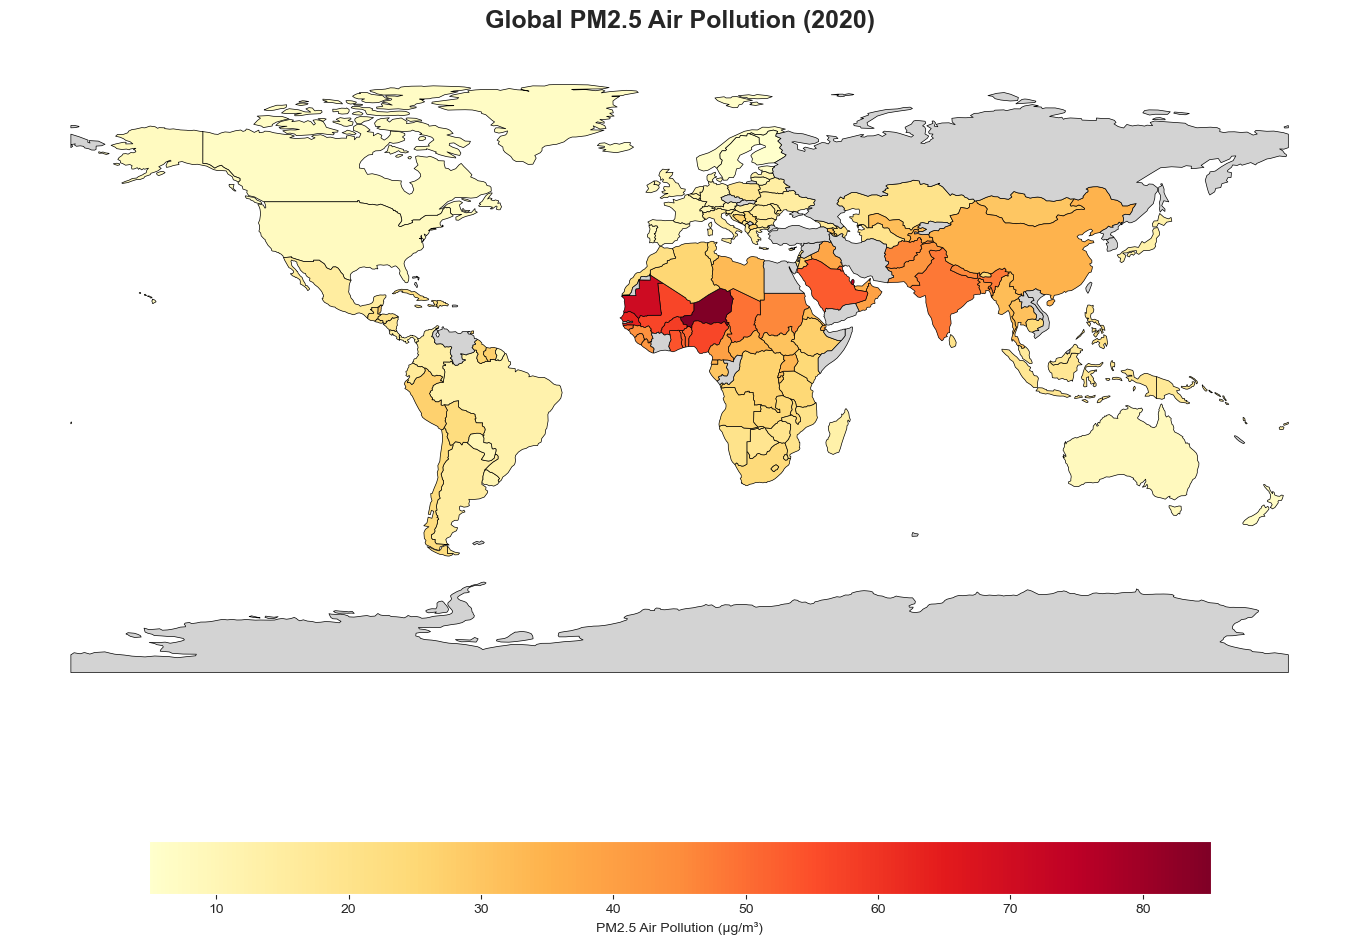

Saved: spatial_energy_map.png


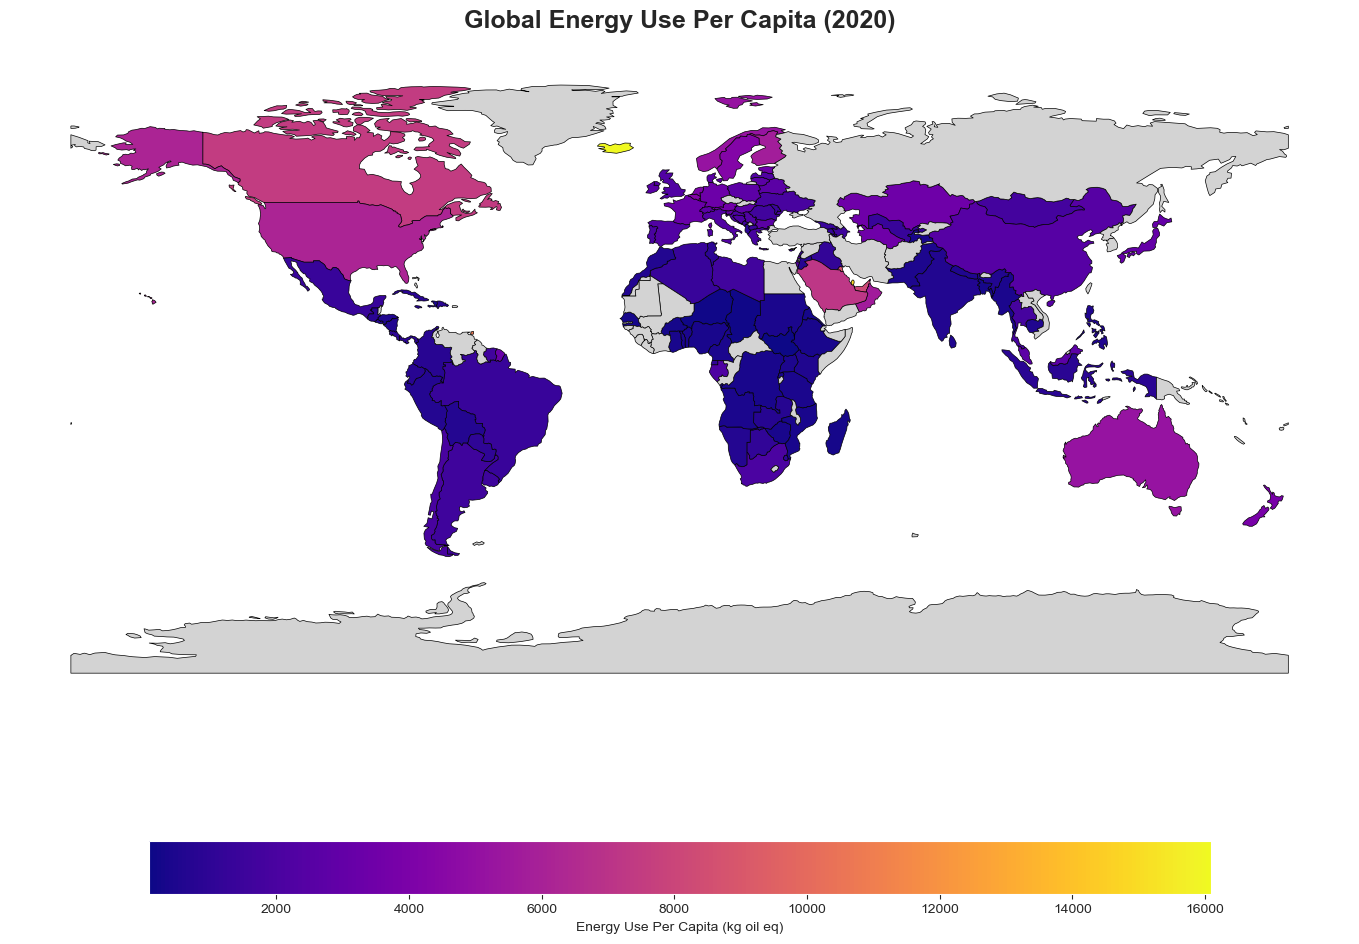


Static choropleth maps created successfully


In [7]:
# Create choropleth maps for key indicators

# PM2.5 Air Pollution Map
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
gdf.plot(column='pm25_air_pollution', ax=ax, legend=True,
         cmap='YlOrRd', edgecolor='black', linewidth=0.5,
         legend_kwds={'label': "PM2.5 Air Pollution (μg/m³)",
                      'orientation': "horizontal",
                      'shrink': 0.6},
         missing_kwds={'color': 'lightgray', 'label': 'No Data'})
ax.set_title('Global PM2.5 Air Pollution (2020)', fontsize=18, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/spatial_pm25_map.png', dpi=300, bbox_inches='tight')
print("Saved: spatial_pm25_map.png")
plt.show()

# Energy Use Per Capita Map
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
gdf.plot(column='energy_use_per_capita', ax=ax, legend=True,
         cmap='plasma', edgecolor='black', linewidth=0.5,
         legend_kwds={'label': "Energy Use Per Capita (kg oil eq)",
                      'orientation': "horizontal",
                      'shrink': 0.6},
         missing_kwds={'color': 'lightgray', 'label': 'No Data'})
ax.set_title('Global Energy Use Per Capita (2020)', fontsize=18, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/spatial_energy_map.png', dpi=300, bbox_inches='tight')
print("Saved: spatial_energy_map.png")
plt.show()

print("\nStatic choropleth maps created successfully")


### 2.2 Interactive Choropleth Maps

In [10]:
# Create interactive maps using Plotly

print("PREPARING DATA FOR INTERACTIVE MAPS")
print("=" * 80)

# Check available columns in gdf
print("\nAvailable columns in geodataframe:")
print([col for col in gdf.columns if 'iso' in col.lower() or 'a3' in col.lower()])

# Find ISO-3 code column (handles different naming conventions)
iso_col = None
possible_iso_cols = ['ISO_A3', 'iso_a3', 'ADM0_A3', 'SOV_A3', 'ISO3', 'iso3']
for col in possible_iso_cols:
    if col in gdf.columns:
        iso_col = col
        print(f"\nFound ISO code column: {iso_col}")
        break

if iso_col is None:
    print("\nWarning: No ISO-3 code column found in shapefile")
    print("Adding ISO codes manually for major countries...")

    # Manual mapping of country names to ISO-3 codes
    iso_mapping = {
        'United States': 'USA', 'China': 'CHN', 'India': 'IND', 'Brazil': 'BRA',
        'Russia': 'RUS', 'Japan': 'JPN', 'Germany': 'DEU', 'United Kingdom': 'GBR',
        'France': 'FRA', 'Italy': 'ITA', 'Canada': 'CAN', 'Korea, Rep.': 'KOR',
        'Spain': 'ESP', 'Mexico': 'MEX', 'Indonesia': 'IDN', 'Australia': 'AUS',
        'Turkey': 'TUR', 'Saudi Arabia': 'SAU', 'Netherlands': 'NLD', 'Poland': 'POL',
        'Argentina': 'ARG', 'South Africa': 'ZAF', 'Thailand': 'THA', 'Egypt': 'EGY',
        'Pakistan': 'PAK', 'Bangladesh': 'BGD', 'Vietnam': 'VNM', 'Philippines': 'PHL',
        'Iran': 'IRN', 'Nigeria': 'NGA', 'Malaysia': 'MYS', 'Colombia': 'COL',
        'Chile': 'CHL', 'Peru': 'PER', 'Venezuela': 'VEN', 'Ukraine': 'UKR',
        'Belgium': 'BEL', 'Sweden': 'SWE', 'Austria': 'AUT', 'Norway': 'NOR',
        'Denmark': 'DNK', 'Finland': 'FIN', 'Portugal': 'PRT', 'Greece': 'GRC',
        'Czech Republic': 'CZE', 'Hungary': 'HUN', 'Romania': 'ROU', 'Israel': 'ISR',
        'New Zealand': 'NZL', 'Singapore': 'SGP', 'Ireland': 'IRL', 'Switzerland': 'CHE'
    }

    gdf['iso_a3_clean'] = gdf['country_name'].map(iso_mapping)

    # Fill remaining with name_clean for fallback
    gdf['iso_a3_clean'] = gdf['iso_a3_clean'].fillna(gdf.get('name_clean', gdf['name']))

else:
    # Use the found ISO column
    gdf['iso_a3_clean'] = gdf[iso_col]

# Remove any invalid ISO codes (like -99, None, etc.)
gdf['iso_a3_clean'] = gdf['iso_a3_clean'].replace(['-99', 'nan', 'None'], None)

print(f"\nCountries with valid ISO codes: {gdf['iso_a3_clean'].notna().sum()}")

# Create interactive PM2.5 map
print("\nCreating PM2.5 interactive map...")

try:
    # Filter to countries with valid data
    plot_df = gdf[gdf['pm25_air_pollution'].notna() & gdf['iso_a3_clean'].notna()].copy()

    if len(plot_df) > 0:
        fig = px.choropleth(plot_df,
                            locations="iso_a3_clean",
                            locationmode='ISO-3',
                            color="pm25_air_pollution",
                            hover_name="country_name",
                            hover_data={
                                'pm25_air_pollution': ':.2f',
                                'energy_use_per_capita': ':.2f',
                                'gdp_per_capita': ':.2f',
                                'iso_a3_clean': False
                            },
                            color_continuous_scale='YlOrRd',
                            title="Global PM2.5 Air Pollution (2020)",
                            labels={'pm25_air_pollution': 'PM2.5 (μg/m³)'})

        fig.update_layout(
            geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
            height=600,
            font=dict(size=12)
        )

        fig.write_html('../data/processed/interactive_pm25_map.html')
        print("Saved: interactive_pm25_map.html")
        fig.show()

        # Create interactive energy use map
        print("\nCreating energy use interactive map...")

        plot_df2 = gdf[gdf['energy_use_per_capita'].notna() & gdf['iso_a3_clean'].notna()].copy()

        if len(plot_df2) > 0:
            fig2 = px.choropleth(plot_df2,
                                 locations="iso_a3_clean",
                                 locationmode='ISO-3',
                                 color="energy_use_per_capita",
                                 hover_name="country_name",
                                 hover_data={
                                     'energy_use_per_capita': ':.2f',
                                     'pm25_air_pollution': ':.2f',
                                     'forest_area_percent': ':.2f',
                                     'iso_a3_clean': False
                                 },
                                 color_continuous_scale='Viridis',
                                 title="Global Energy Use Per Capita (2020)",
                                 labels={'energy_use_per_capita': 'Energy Use (kg oil eq)'})

            fig2.update_layout(
                geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
                height=600,
                font=dict(size=12)
            )

            fig2.write_html('../data/processed/interactive_energy_map.html')
            print("Saved: interactive_energy_map.html")
            fig2.show()

        print("\nInteractive choropleth maps created successfully")
    else:
        print("\nNo countries with valid ISO codes and data - skipping interactive maps")

except Exception as e:
    print(f"\nError creating interactive maps: {e}")
    print("Continuing with analysis...")


PREPARING DATA FOR INTERACTIVE MAPS

Available columns in geodataframe:
['SOV_A3', 'ADM0_A3', 'GU_A3', 'SU_A3', 'BRK_A3', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A3', 'ADM0_ISO', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'ADM0_A3_ID', 'ADM0_A3_PL', 'ADM0_A3_GR', 'ADM0_A3_IT', 'ADM0_A3_NL', 'ADM0_A3_SE', 'ADM0_A3_BD', 'ADM0_A3_UA', 'ADM0_A3_UN', 'ADM0_A3_WB', 'FCLASS_ISO']

Found ISO code column: ISO_A3

Countries with valid ISO codes: 172

Creating PM2.5 interactive map...
Saved: interactive_pm25_map.html



Creating energy use interactive map...
Saved: interactive_energy_map.html



Interactive choropleth maps created successfully


### 2.3 Multiple Indicator Maps

Saved: spatial_multi_indicator_maps.png


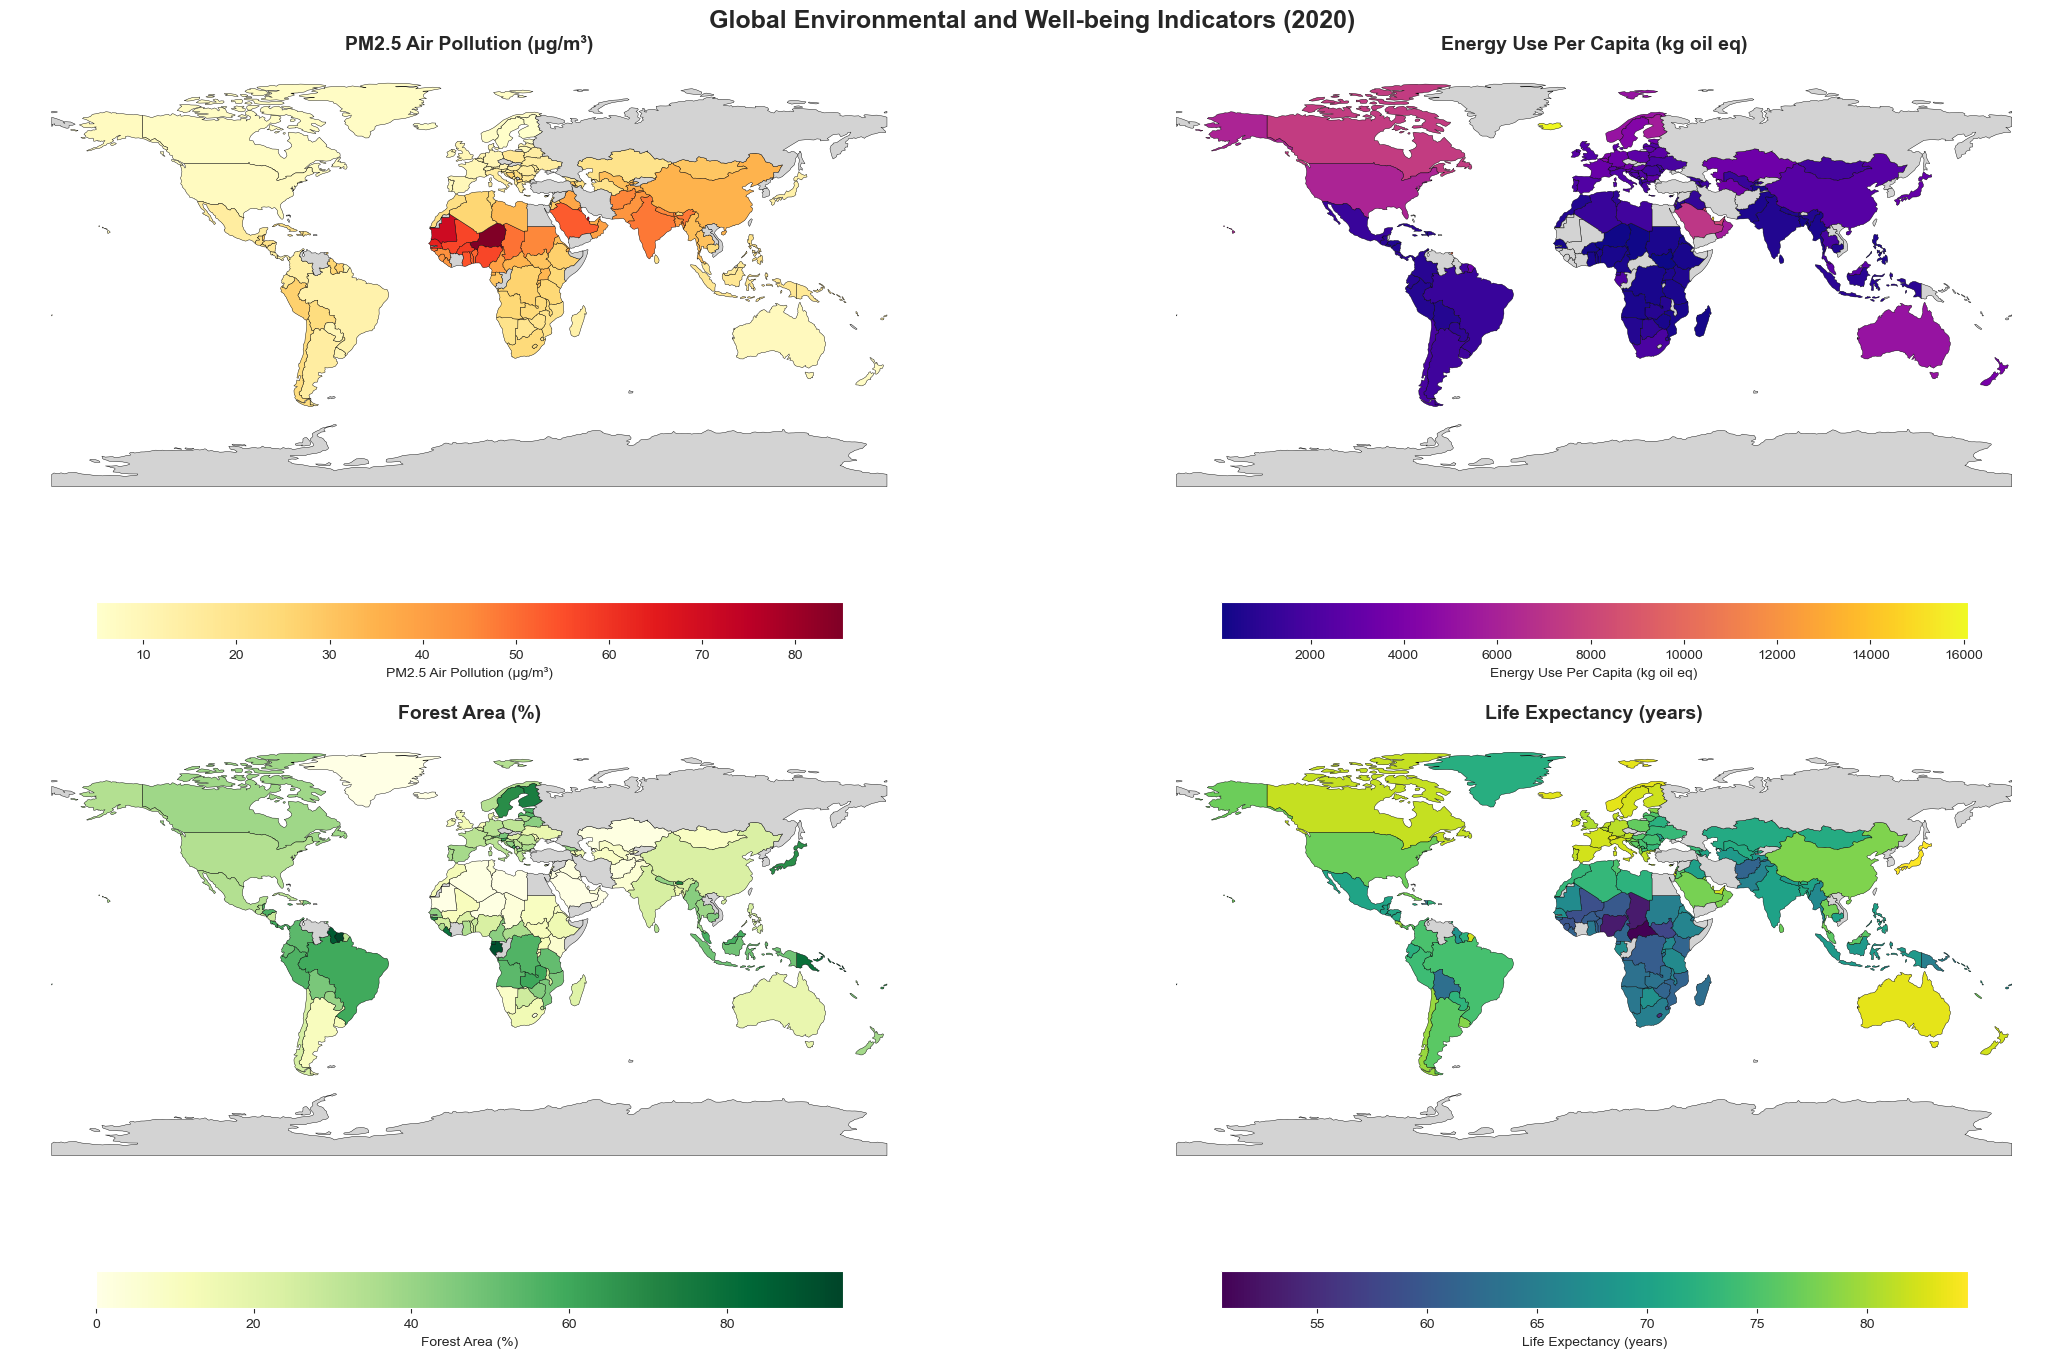


Multiple indicator maps created successfully


In [11]:
# Create maps for multiple environmental indicators
indicators = [
    ('pm25_air_pollution', 'PM2.5 Air Pollution (μg/m³)', 'YlOrRd'),
    ('energy_use_per_capita', 'Energy Use Per Capita (kg oil eq)', 'plasma'),
    ('forest_area_percent', 'Forest Area (%)', 'YlGn'),
    ('life_expectancy', 'Life Expectancy (years)', 'viridis')
]

fig, axes = plt.subplots(2, 2, figsize=(24, 14))
axes = axes.flatten()

for idx, (indicator, title, cmap) in enumerate(indicators):
    gdf.plot(column=indicator, ax=axes[idx], legend=True,
             cmap=cmap, edgecolor='black', linewidth=0.3,
             legend_kwds={'label': title, 'orientation': 'horizontal', 'shrink': 0.6},
             missing_kwds={'color': 'lightgray', 'label': 'No Data'})
    axes[idx].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

plt.suptitle('Global Environmental and Well-being Indicators (2020)',
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../data/processed/spatial_multi_indicator_maps.png', dpi=300, bbox_inches='tight')
print("Saved: spatial_multi_indicator_maps.png")
plt.show()

print("\nMultiple indicator maps created successfully")


## 3. Spatial Statistics

### 3.1 Global Spatial Autocorrelation (Moran's I)

In [12]:
# Calculate Global Spatial Autocorrelation (Moran's I)
# Note: Using simplified approach without pysal for compatibility

print("GLOBAL SPATIAL AUTOCORRELATION ANALYSIS")
print("=" * 80)

# Filter countries with valid PM2.5 data and geometry
gdf_valid = gdf[gdf['pm25_air_pollution'].notna()].copy()
print(f"\nAnalyzing {len(gdf_valid)} countries with valid PM2.5 data")

# Calculate pairwise distances between country centroids
from scipy.spatial import distance_matrix
centroids = np.array([(geom.centroid.x, geom.centroid.y) for geom in gdf_valid.geometry])
dist_matrix = distance_matrix(centroids, centroids)

# Create inverse distance weights (closer countries = higher weight)
# Use threshold distance to define neighbors
threshold_dist = 1500  # km (approximate)
weights_matrix = np.where((dist_matrix > 0) & (dist_matrix < threshold_dist),
                          1.0 / dist_matrix, 0)

# Row-standardize weights
row_sums = weights_matrix.sum(axis=1, keepdims=True)
weights_matrix = np.where(row_sums > 0, weights_matrix / row_sums, 0)

# Calculate Moran's I manually
pm25_values = gdf_valid['pm25_air_pollution'].values
mean_pm25 = pm25_values.mean()
n = len(pm25_values)

# Deviation from mean
z = pm25_values - mean_pm25

# Moran's I formula
numerator = np.sum(weights_matrix * np.outer(z, z))
denominator = np.sum(z ** 2)
W = np.sum(weights_matrix)

morans_i = (n / W) * (numerator / denominator)

print(f"\nMoran's I Statistic: {morans_i:.4f}")
print(f"\nInterpretation:")
if morans_i > 0.3:
    print(f"  Strong POSITIVE spatial autocorrelation")
    print(f"  Similar PM2.5 values are clustered together")
elif morans_i > 0:
    print(f"  Weak to moderate POSITIVE spatial autocorrelation")
    print(f"  Some tendency for similar values to cluster")
elif morans_i < -0.1:
    print(f"  NEGATIVE spatial autocorrelation")
    print(f"  Dissimilar values tend to be near each other")
else:
    print(f"  Random spatial pattern (no significant autocorrelation)")

print("\nMoran's I calculation complete")
print("Note: Using distance-based weights with {:.0f} km threshold".format(threshold_dist))


GLOBAL SPATIAL AUTOCORRELATION ANALYSIS

Analyzing 146 countries with valid PM2.5 data

Moran's I Statistic: 0.2094

Interpretation:
  Weak to moderate POSITIVE spatial autocorrelation
  Some tendency for similar values to cluster

Moran's I calculation complete
Note: Using distance-based weights with 1500 km threshold


### 3.2 Local Spatial Autocorrelation (LISA)

LOCAL SPATIAL AUTOCORRELATION (LISA)

LISA Cluster Classification:
  Low-Low (Coldspot): 63 countries
  High-High (Hotspot): 50 countries
  Low-High (Outlier): 26 countries
  High-Low (Outlier): 7 countries

Saved: spatial_lisa_clusters.png


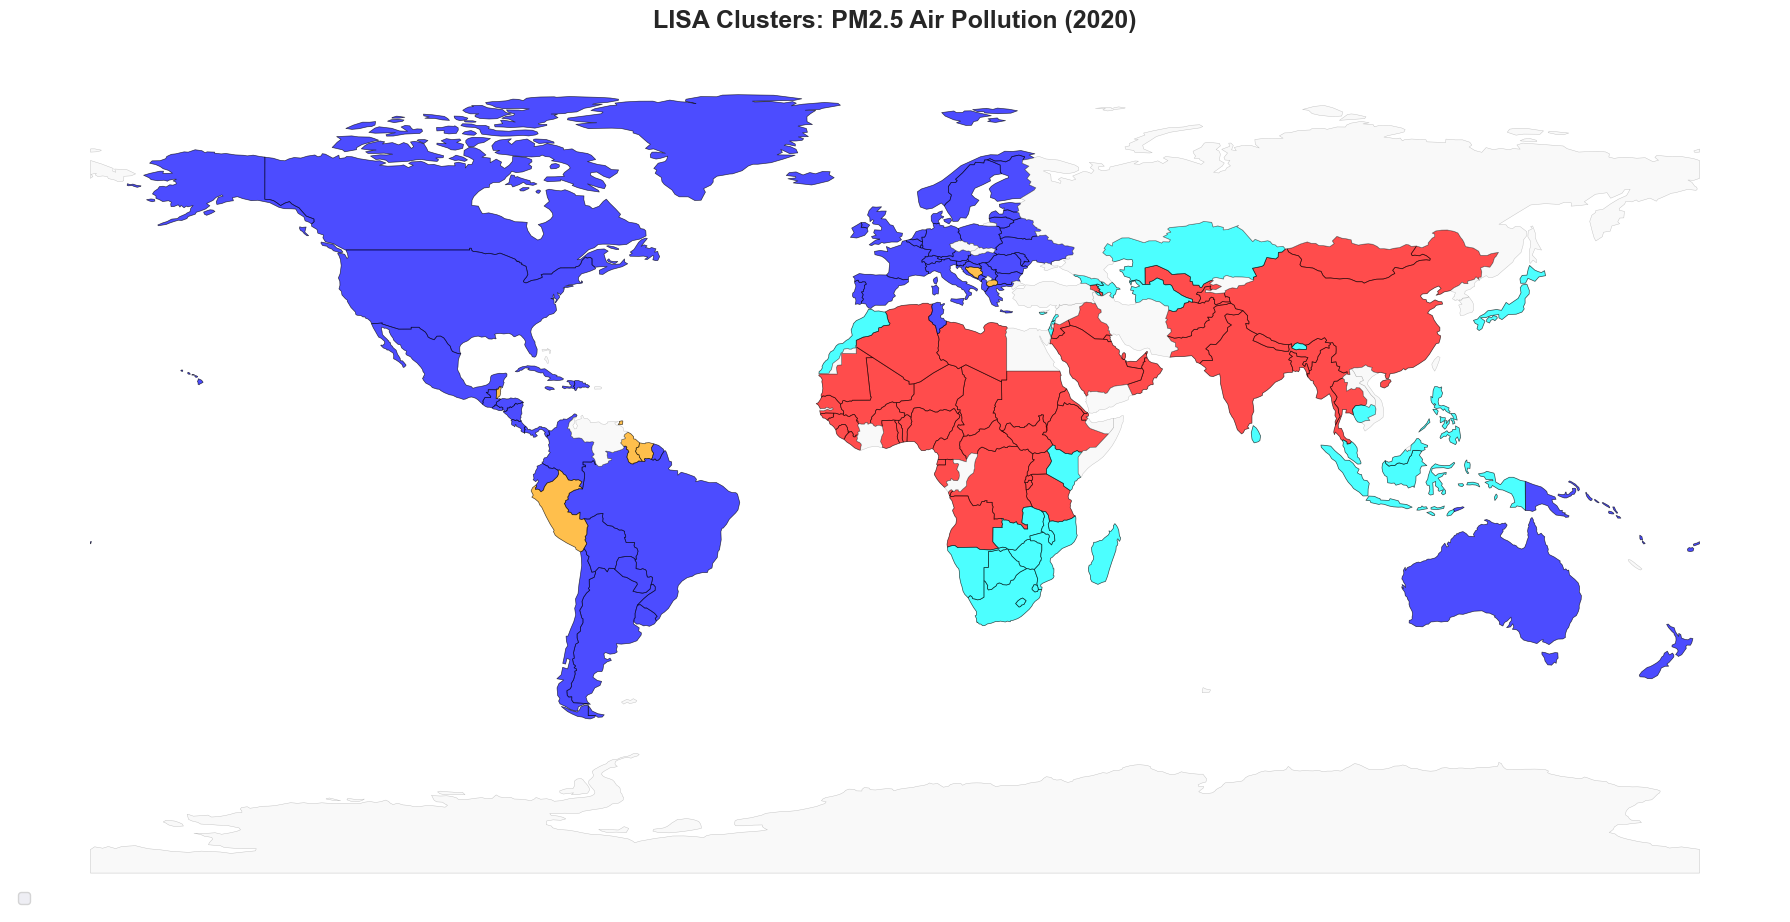


LISA analysis complete


In [13]:
# Local Indicators of Spatial Association (LISA)
print("LOCAL SPATIAL AUTOCORRELATION (LISA)")
print("=" * 80)

# Calculate local Moran's I for each country
pm25_values = gdf_valid['pm25_air_pollution'].values
mean_pm25 = pm25_values.mean()
std_pm25 = pm25_values.std()

# Standardize values
z_values = (pm25_values - mean_pm25) / std_pm25

# Calculate local Moran's I
local_i = []
for i in range(len(gdf_valid)):
    # Get neighbors (countries within threshold distance)
    neighbors = weights_matrix[i] > 0
    if neighbors.sum() > 0:
        # Local Moran's I = z_i * sum(w_ij * z_j)
        local_moran = z_values[i] * np.sum(weights_matrix[i] * z_values)
        local_i.append(local_moran)
    else:
        local_i.append(0)

gdf_valid['local_morans_i'] = local_i

# Classify into quadrants
# High-High (HH): High value, high neighbors (hotspots)
# Low-Low (LL): Low value, low neighbors (coldspots)
# High-Low (HL): High value, low neighbors (outliers)
# Low-High (LH): Low value, high neighbors (outliers)

def classify_lisa(row):
    pm25 = row['pm25_air_pollution']
    local_i = row['local_morans_i']

    if pm25 > mean_pm25 and local_i > 0:
        return 'High-High (Hotspot)'
    elif pm25 < mean_pm25 and local_i > 0:
        return 'Low-Low (Coldspot)'
    elif pm25 > mean_pm25 and local_i < 0:
        return 'High-Low (Outlier)'
    elif pm25 < mean_pm25 and local_i < 0:
        return 'Low-High (Outlier)'
    else:
        return 'Not Significant'

gdf_valid['lisa_cluster'] = gdf_valid.apply(classify_lisa, axis=1)

# Count clusters
print(f"\nLISA Cluster Classification:")
cluster_counts = gdf_valid['lisa_cluster'].value_counts()
for cluster, count in cluster_counts.items():
    print(f"  {cluster}: {count} countries")

# Visualize LISA clusters
fig, ax = plt.subplots(figsize=(18, 10))

# Color mapping for clusters
color_map = {
    'High-High (Hotspot)': 'red',
    'Low-Low (Coldspot)': 'blue',
    'High-Low (Outlier)': 'orange',
    'Low-High (Outlier)': 'cyan',
    'Not Significant': 'lightgray'
}

for cluster in color_map.keys():
    subset = gdf_valid[gdf_valid['lisa_cluster'] == cluster]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color_map[cluster], edgecolor='black',
                    linewidth=0.5, label=cluster, alpha=0.7)

# Plot countries without data
gdf_no_data = gdf[gdf['pm25_air_pollution'].isna()]
gdf_no_data.plot(ax=ax, color='whitesmoke', edgecolor='gray',
                 linewidth=0.3, label='No Data', alpha=0.5)

ax.set_title('LISA Clusters: PM2.5 Air Pollution (2020)',
             fontsize=18, fontweight='bold', pad=20)
ax.axis('off')
ax.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/spatial_lisa_clusters.png', dpi=300, bbox_inches='tight')
print("\nSaved: spatial_lisa_clusters.png")
plt.show()

print("\nLISA analysis complete")


## 4. Hotspot Analysis

### 4.1 Identify Environmental Hotspots and Coldspots

In [14]:
# Identify and analyze environmental hotspots and coldspots
print("HOTSPOT AND COLDSPOT ANALYSIS")
print("=" * 80)

# Identify hotspots (High-High clusters)
hotspots = gdf_valid[gdf_valid['lisa_cluster'] == 'High-High (Hotspot)'].copy()
hotspots_sorted = hotspots.sort_values('pm25_air_pollution', ascending=False)

print(f"\nEnvironmental HOTSPOTS (High PM2.5, High Neighbors):")
print(f"Total: {len(hotspots)} countries/regions")
if len(hotspots) > 0:
    print("\nTop Hotspots:")
    for idx, row in hotspots_sorted.head(10).iterrows():
        print(f"  {row['country_name']}: {row['pm25_air_pollution']:.2f} μg/m³")

# Identify coldspots (Low-Low clusters)
coldspots = gdf_valid[gdf_valid['lisa_cluster'] == 'Low-Low (Coldspot)'].copy()
coldspots_sorted = coldspots.sort_values('pm25_air_pollution')

print(f"\nEnvironmental COLDSPOTS (Low PM2.5, Low Neighbors):")
print(f"Total: {len(coldspots)} countries/regions")
if len(coldspots) > 0:
    print("\nTop Coldspots (Best Air Quality):")
    for idx, row in coldspots_sorted.head(10).iterrows():
        print(f"  {row['country_name']}: {row['pm25_air_pollution']:.2f} μg/m³")

# Statistical comparison
if len(hotspots) > 0 and len(coldspots) > 0:
    print(f"\nStatistical Comparison:")
    print(f"  Hotspot mean PM2.5: {hotspots['pm25_air_pollution'].mean():.2f} μg/m³")
    print(f"  Coldspot mean PM2.5: {coldspots['pm25_air_pollution'].mean():.2f} μg/m³")
    print(f"  Difference: {hotspots['pm25_air_pollution'].mean() - coldspots['pm25_air_pollution'].mean():.2f} μg/m³")

print("\nHotspot analysis complete")


HOTSPOT AND COLDSPOT ANALYSIS

Environmental HOTSPOTS (High PM2.5, High Neighbors):
Total: 50 countries/regions

Top Hotspots:
  Niger: 85.12 μg/m³
  Qatar: 75.66 μg/m³
  Mauritania: 70.82 μg/m³
  Senegal: 63.74 μg/m³
  Burkina Faso: 58.47 μg/m³
  Mali: 56.78 μg/m³
  Nigeria: 56.53 μg/m³
  Ghana: 54.24 μg/m³
  Kuwait: 53.72 μg/m³
  Saudi Arabia: 53.15 μg/m³

Environmental COLDSPOTS (Low PM2.5, Low Neighbors):
Total: 63 countries/regions

Top Coldspots (Best Air Quality):
  Finland: 4.90 μg/m³
  Iceland: 5.11 μg/m³
  Sweden: 5.64 μg/m³
  Norway: 6.06 μg/m³
  Estonia: 6.15 μg/m³
  New Zealand: 6.49 μg/m³
  Greenland: 6.56 μg/m³
  Canada: 6.57 μg/m³
  United States: 7.81 μg/m³
  Ireland: 8.17 μg/m³

Statistical Comparison:
  Hotspot mean PM2.5: 41.95 μg/m³
  Coldspot mean PM2.5: 13.46 μg/m³
  Difference: 28.49 μg/m³

Hotspot analysis complete


## 5. Regional Comparisons

### 5.1 Compare Indicators Across Continents

REGIONAL COMPARISON ANALYSIS

Comparing 146 countries across 6 continents

PM2.5 by Continent:
               count   mean  median    std    min    max
continent                                               
Africa            44  36.23   31.82  15.89  12.75  85.12
Asia              34  31.20   30.12  14.15  12.84  75.66
Europe            35  12.61   11.22   5.38   4.90  26.60
North America     16  17.16   18.62   6.53   6.56  28.65
Oceania            6  12.08   13.19   4.02   6.49  17.31
South America     11  18.60   16.66   6.70  10.09  27.31

Saved: spatial_regional_comparison.png


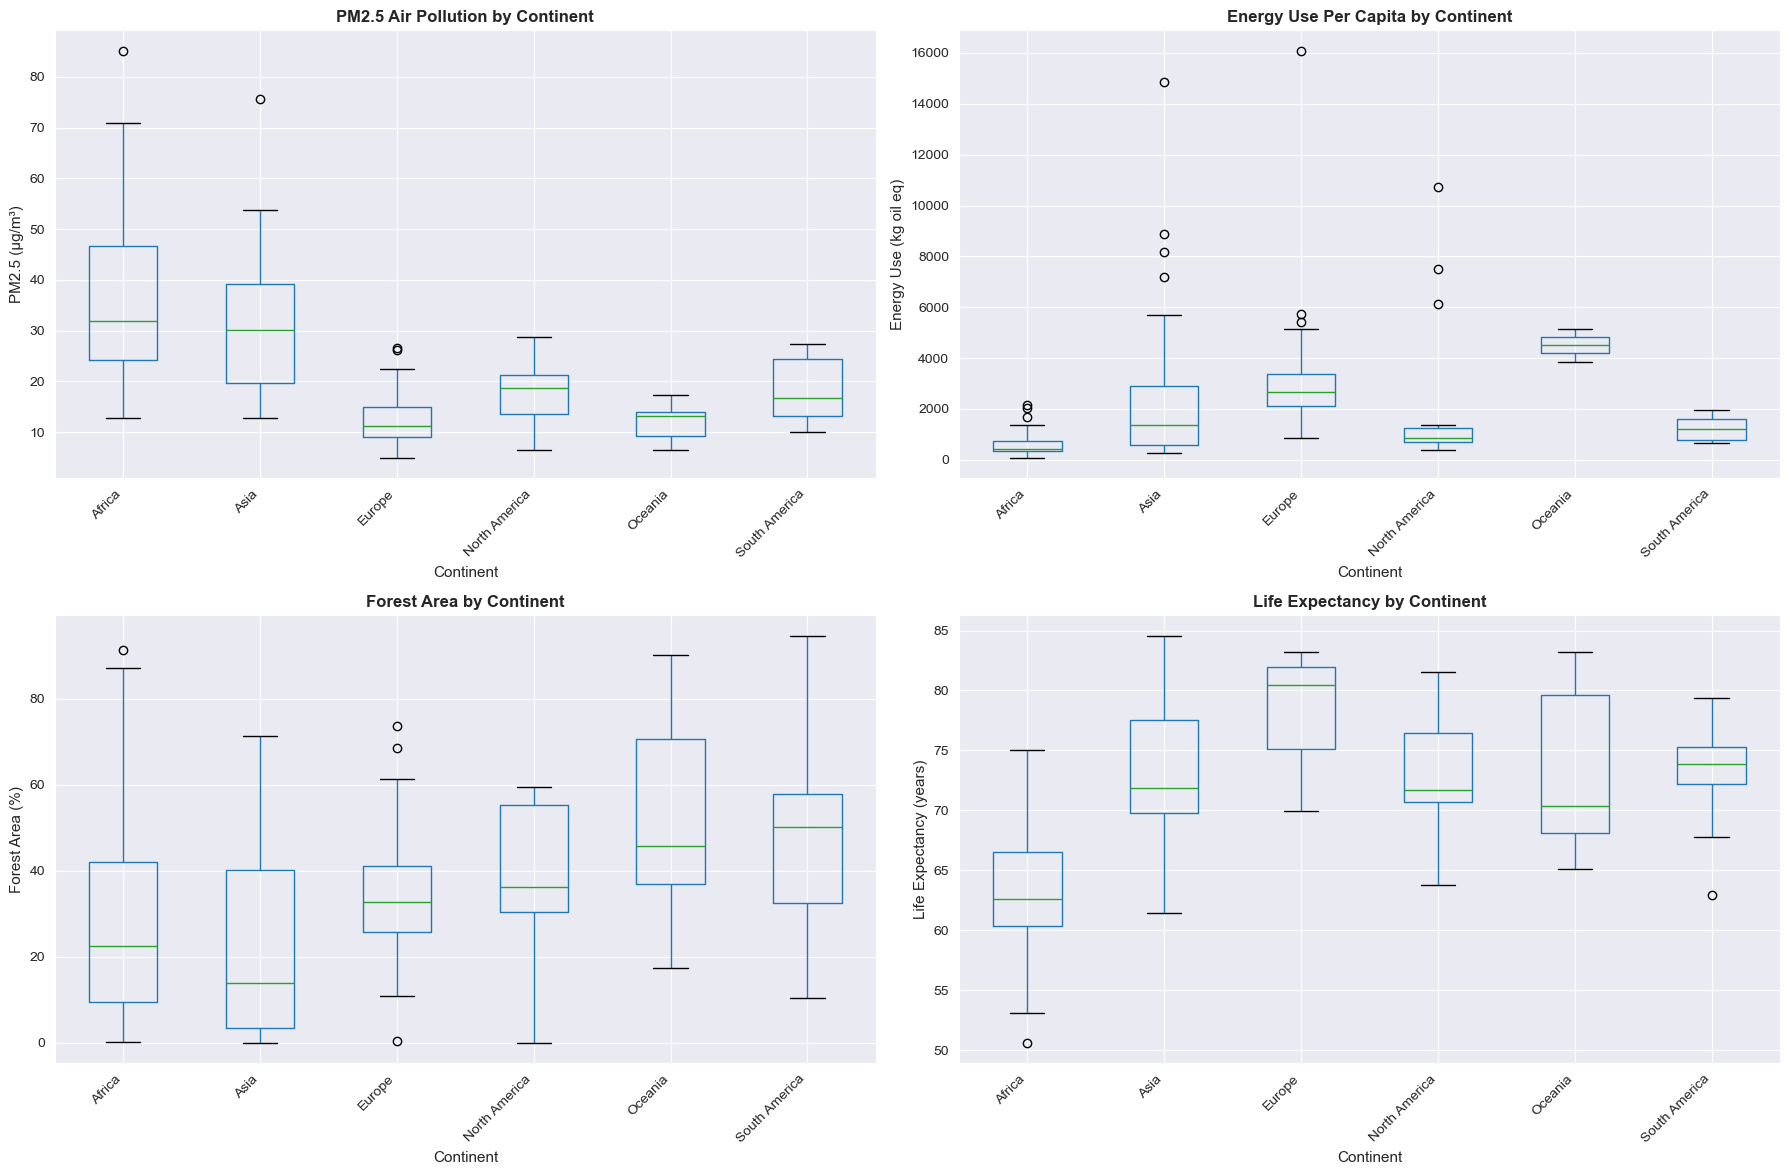


Regional comparison analysis complete


In [15]:
# Compare environmental indicators by continent/region
print("REGIONAL COMPARISON ANALYSIS")
print("=" * 80)

# Filter valid data
comparison_df = gdf[gdf['pm25_air_pollution'].notna()].copy()

print(f"\nComparing {len(comparison_df)} countries across {comparison_df['continent'].nunique()} continents")

# Regional statistics for PM2.5
regional_stats = comparison_df.groupby('continent')['pm25_air_pollution'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2)

print(f"\nPM2.5 by Continent:")
print(regional_stats)

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# PM2.5 by continent (box plot)
ax1 = axes[0, 0]
comparison_df.boxplot(column='pm25_air_pollution', by='continent', ax=ax1)
ax1.set_title('PM2.5 Air Pollution by Continent', fontsize=12, fontweight='bold')
ax1.set_xlabel('Continent', fontsize=11)
ax1.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('')  # Remove default title

# Energy use by continent
ax2 = axes[0, 1]
energy_df = gdf[gdf['energy_use_per_capita'].notna()]
if len(energy_df) > 0:
    energy_df.boxplot(column='energy_use_per_capita', by='continent', ax=ax2)
    ax2.set_title('Energy Use Per Capita by Continent', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Continent', fontsize=11)
    ax2.set_ylabel('Energy Use (kg oil eq)', fontsize=11)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('')

# Forest area by continent
ax3 = axes[1, 0]
forest_df = gdf[gdf['forest_area_percent'].notna()]
if len(forest_df) > 0:
    forest_df.boxplot(column='forest_area_percent', by='continent', ax=ax3)
    ax3.set_title('Forest Area by Continent', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Continent', fontsize=11)
    ax3.set_ylabel('Forest Area (%)', fontsize=11)
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('')

# Life expectancy by continent
ax4 = axes[1, 1]
life_df = gdf[gdf['life_expectancy'].notna()]
if len(life_df) > 0:
    life_df.boxplot(column='life_expectancy', by='continent', ax=ax4)
    ax4.set_title('Life Expectancy by Continent', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Continent', fontsize=11)
    ax4.set_ylabel('Life Expectancy (years)', fontsize=11)
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/processed/spatial_regional_comparison.png', dpi=300, bbox_inches='tight')
print("\nSaved: spatial_regional_comparison.png")
plt.show()

print("\nRegional comparison analysis complete")


### 5.2 Ranking Countries/Regions

COUNTRY RANKING ANALYSIS

Top 15 Best Performers (Lowest PM2.5 Air Pollution):
 1. Finland                          4.90 μg/m³
 2. Iceland                          5.11 μg/m³
 3. Sweden                           5.64 μg/m³
 4. Norway                           6.06 μg/m³
 5. Estonia                          6.15 μg/m³
 6. New Zealand                      6.49 μg/m³
 7. Greenland                        6.56 μg/m³
 8. Canada                           6.57 μg/m³
 9. United States                    7.81 μg/m³
10. Ireland                          8.17 μg/m³
11. Australia                        8.25 μg/m³
12. Portugal                         8.45 μg/m³
13. Luxembourg                       8.67 μg/m³
14. Switzerland                      9.06 μg/m³
15. Denmark                          9.07 μg/m³

Top 15 Worst Performers (Highest PM2.5 Air Pollution):
 1. Niger                           85.12 μg/m³
 2. Qatar                           75.66 μg/m³
 3. Mauritania                      70.82 μg/m³
 

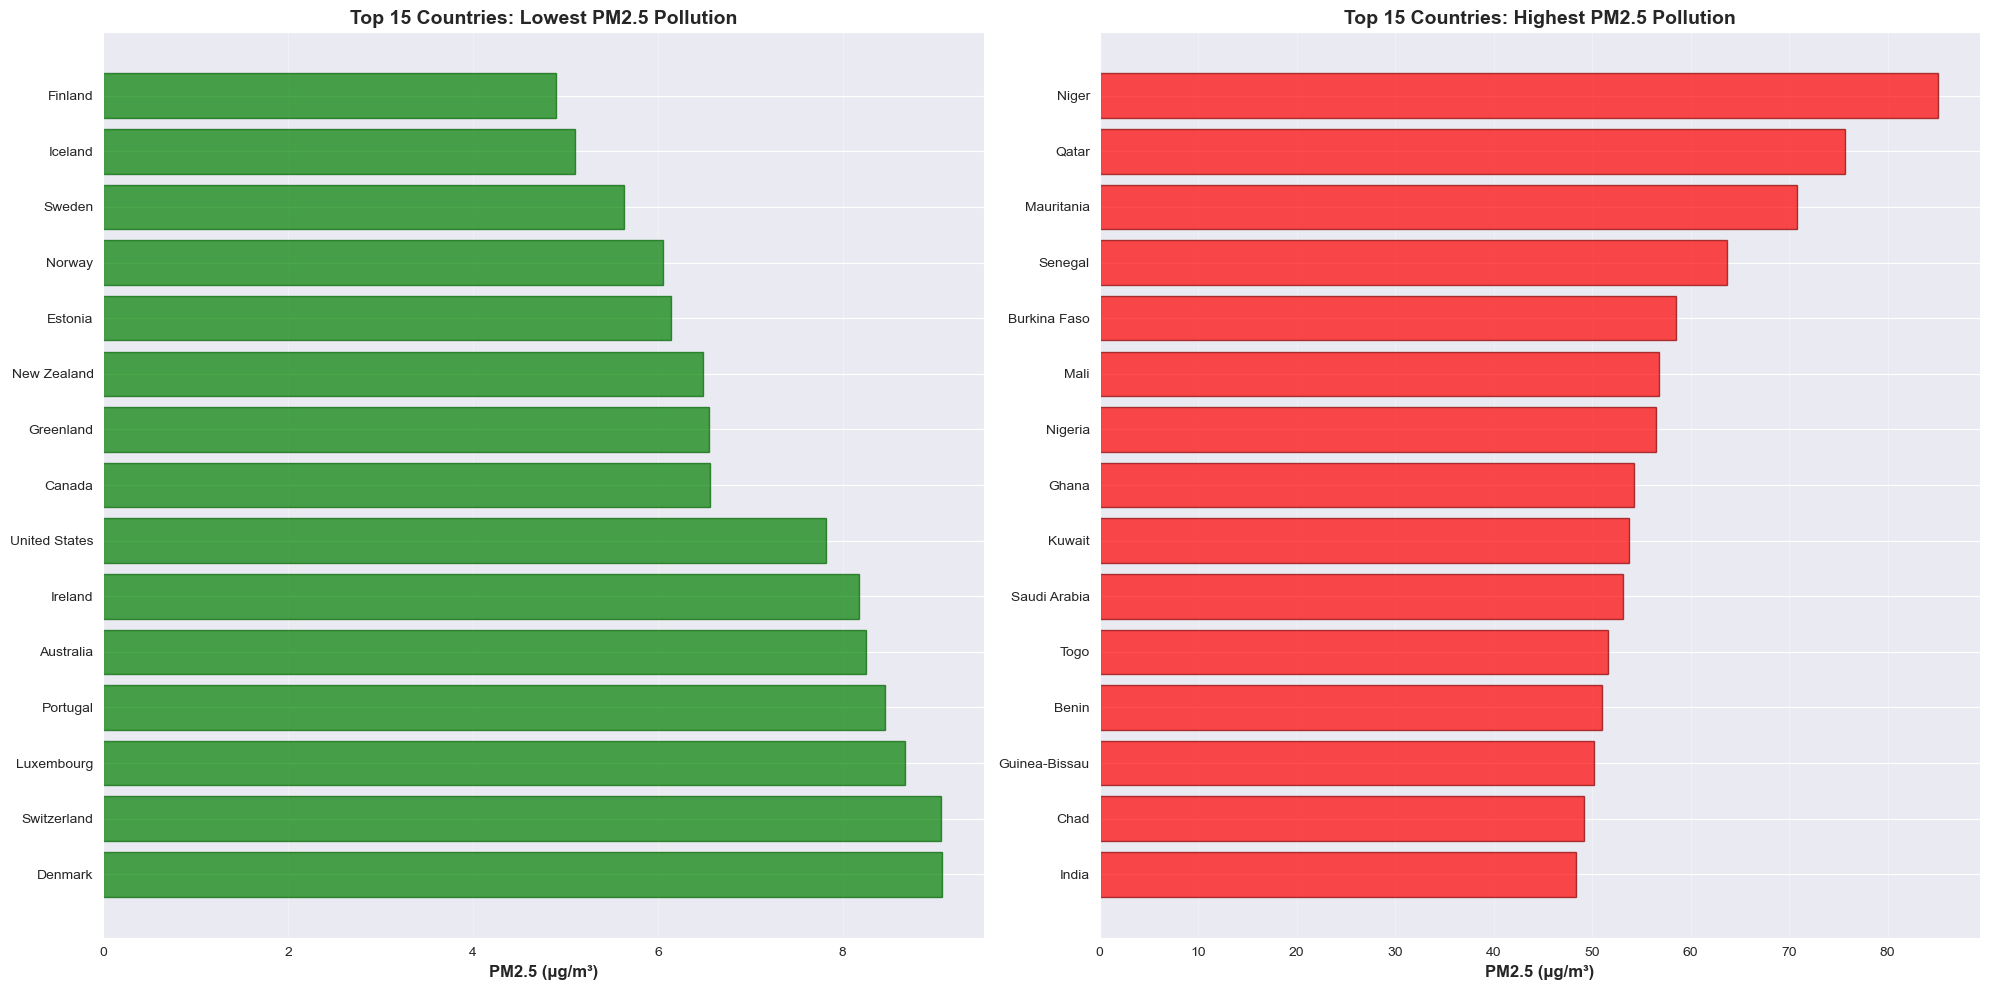


Country ranking analysis complete


In [16]:
# Rank countries by environmental performance
print("COUNTRY RANKING ANALYSIS")
print("=" * 80)

# Best performers (lowest PM2.5)
ranking_df = gdf[gdf['pm25_air_pollution'].notna()].copy()

best_performers = ranking_df.nsmallest(15, 'pm25_air_pollution')[
    ['country_name', 'pm25_air_pollution', 'energy_use_per_capita',
     'forest_area_percent', 'life_expectancy']
]

print(f"\nTop 15 Best Performers (Lowest PM2.5 Air Pollution):")
print("=" * 80)
for idx, (i, row) in enumerate(best_performers.iterrows(), 1):
    print(f"{idx:2d}. {row['country_name']:<30s} {row['pm25_air_pollution']:6.2f} μg/m³")

# Worst performers (highest PM2.5)
worst_performers = ranking_df.nlargest(15, 'pm25_air_pollution')[
    ['country_name', 'pm25_air_pollution', 'energy_use_per_capita',
     'forest_area_percent', 'life_expectancy']
]

print(f"\nTop 15 Worst Performers (Highest PM2.5 Air Pollution):")
print("=" * 80)
for idx, (i, row) in enumerate(worst_performers.iterrows(), 1):
    print(f"{idx:2d}. {row['country_name']:<30s} {row['pm25_air_pollution']:6.2f} μg/m³")

# Create ranking visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Best performers bar chart
ax1 = axes[0]
best_plot = best_performers.sort_values('pm25_air_pollution')
ax1.barh(best_plot['country_name'], best_plot['pm25_air_pollution'],
         color='green', alpha=0.7, edgecolor='darkgreen')
ax1.set_xlabel('PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Countries: Lowest PM2.5 Pollution', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Worst performers bar chart
ax2 = axes[1]
worst_plot = worst_performers.sort_values('pm25_air_pollution', ascending=False)
ax2.barh(worst_plot['country_name'], worst_plot['pm25_air_pollution'],
         color='red', alpha=0.7, edgecolor='darkred')
ax2.set_xlabel('PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
ax2.set_title('Top 15 Countries: Highest PM2.5 Pollution', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../data/processed/spatial_country_rankings.png', dpi=300, bbox_inches='tight')
print("\nSaved: spatial_country_rankings.png")
plt.show()

print("\nCountry ranking analysis complete")


## 6. Geographically Weighted Regression (GWR)

### 6.1 Build GWR Model

In [17]:
# Geographically Weighted Regression (Simplified Approach)
print("GEOGRAPHICALLY WEIGHTED REGRESSION (GWR)")
print("=" * 80)
print("Note: Using simplified distance-based regression approach")

# Prepare data for spatial regression
regression_df = gdf[(gdf['pm25_air_pollution'].notna()) &
                    (gdf['energy_use_per_capita'].notna()) &
                    (gdf['gdp_per_capita'].notna()) &
                    (gdf['population_total'].notna())].copy()

print(f"\nCountries with complete data: {len(regression_df)}")

if len(regression_df) > 20:
    # Extract coordinates
    coords = np.array([(geom.centroid.x, geom.centroid.y)
                       for geom in regression_df.geometry])

    # Predictors and outcome
    X_vars = ['energy_use_per_capita', 'gdp_per_capita', 'population_total']
    X = regression_df[X_vars].values
    y = regression_df['pm25_air_pollution'].values

    # Standardize for better comparison
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit global OLS for comparison
    from sklearn.linear_model import LinearRegression
    global_model = LinearRegression()
    global_model.fit(X_scaled, y)
    global_r2 = global_model.score(X_scaled, y)

    print(f"\nGlobal OLS Regression:")
    print(f"  R² = {global_r2:.4f}")
    print(f"  Coefficients:")
    for var, coef in zip(X_vars, global_model.coef_):
        print(f"    {var}: {coef:.4f}")

    # Simplified spatial varying coefficients
    # For each location, fit local regression using nearby points
    print(f"\nCalculating spatially varying coefficients...")
    print(f"(Using distance-weighted local regressions)")

    # Store results
    regression_df['energy_coef'] = 0.0
    regression_df['gdp_coef'] = 0.0
    regression_df['local_r2'] = 0.0

    # Calculate distance matrix
    from scipy.spatial import distance_matrix
    dist_mat = distance_matrix(coords, coords)

    # For each location, fit weighted regression
    bandwidth = np.percentile(dist_mat[dist_mat > 0], 25)  # Use 25th percentile

    for i in range(len(regression_df)):
        # Calculate weights based on distance
        distances = dist_mat[i]
        weights = np.exp(-(distances / bandwidth) ** 2)
        weights[i] = 1.0  # Full weight for focal point

        # Fit weighted regression
        try:
            from sklearn.linear_model import Ridge
            local_model = Ridge(alpha=1.0)
            # Apply weights by duplicating observations (simplified approach)
            sample_weight = weights / weights.sum() * len(weights)
            local_model.fit(X_scaled, y, sample_weight=sample_weight)

            # Store coefficients
            regression_df.iloc[i, regression_df.columns.get_loc('energy_coef')] = local_model.coef_[0]
            regression_df.iloc[i, regression_df.columns.get_loc('gdp_coef')] = local_model.coef_[1]
            regression_df.iloc[i, regression_df.columns.get_loc('local_r2')] = local_model.score(X_scaled, y, sample_weight=sample_weight)
        except:
            pass

    print(f"\nSpatially Varying Coefficients Summary:")
    print(f"  Energy coefficient range: [{regression_df['energy_coef'].min():.4f}, {regression_df['energy_coef'].max():.4f}]")
    print(f"  GDP coefficient range: [{regression_df['gdp_coef'].min():.4f}, {regression_df['gdp_coef'].max():.4f}]")
    print(f"  Mean local R²: {regression_df['local_r2'].mean():.4f}")

    print("\nGWR analysis complete")
else:
    print("\nInsufficient data for GWR analysis")


GEOGRAPHICALLY WEIGHTED REGRESSION (GWR)
Note: Using simplified distance-based regression approach

Countries with complete data: 123

Global OLS Regression:
  R² = 0.2247
  Coefficients:
    energy_use_per_capita: 3.9869
    gdp_per_capita: -8.3209
    population_total: 2.1003

Calculating spatially varying coefficients...
(Using distance-weighted local regressions)

Spatially Varying Coefficients Summary:
  Energy coefficient range: [-4.2345, 11.0858]
  GDP coefficient range: [-13.8226, -4.1720]
  Mean local R²: 0.2893

GWR analysis complete


### 6.2 Visualize Spatially Varying Coefficients

VISUALIZING SPATIALLY VARYING COEFFICIENTS
Saved: spatial_gwr_coefficients.png


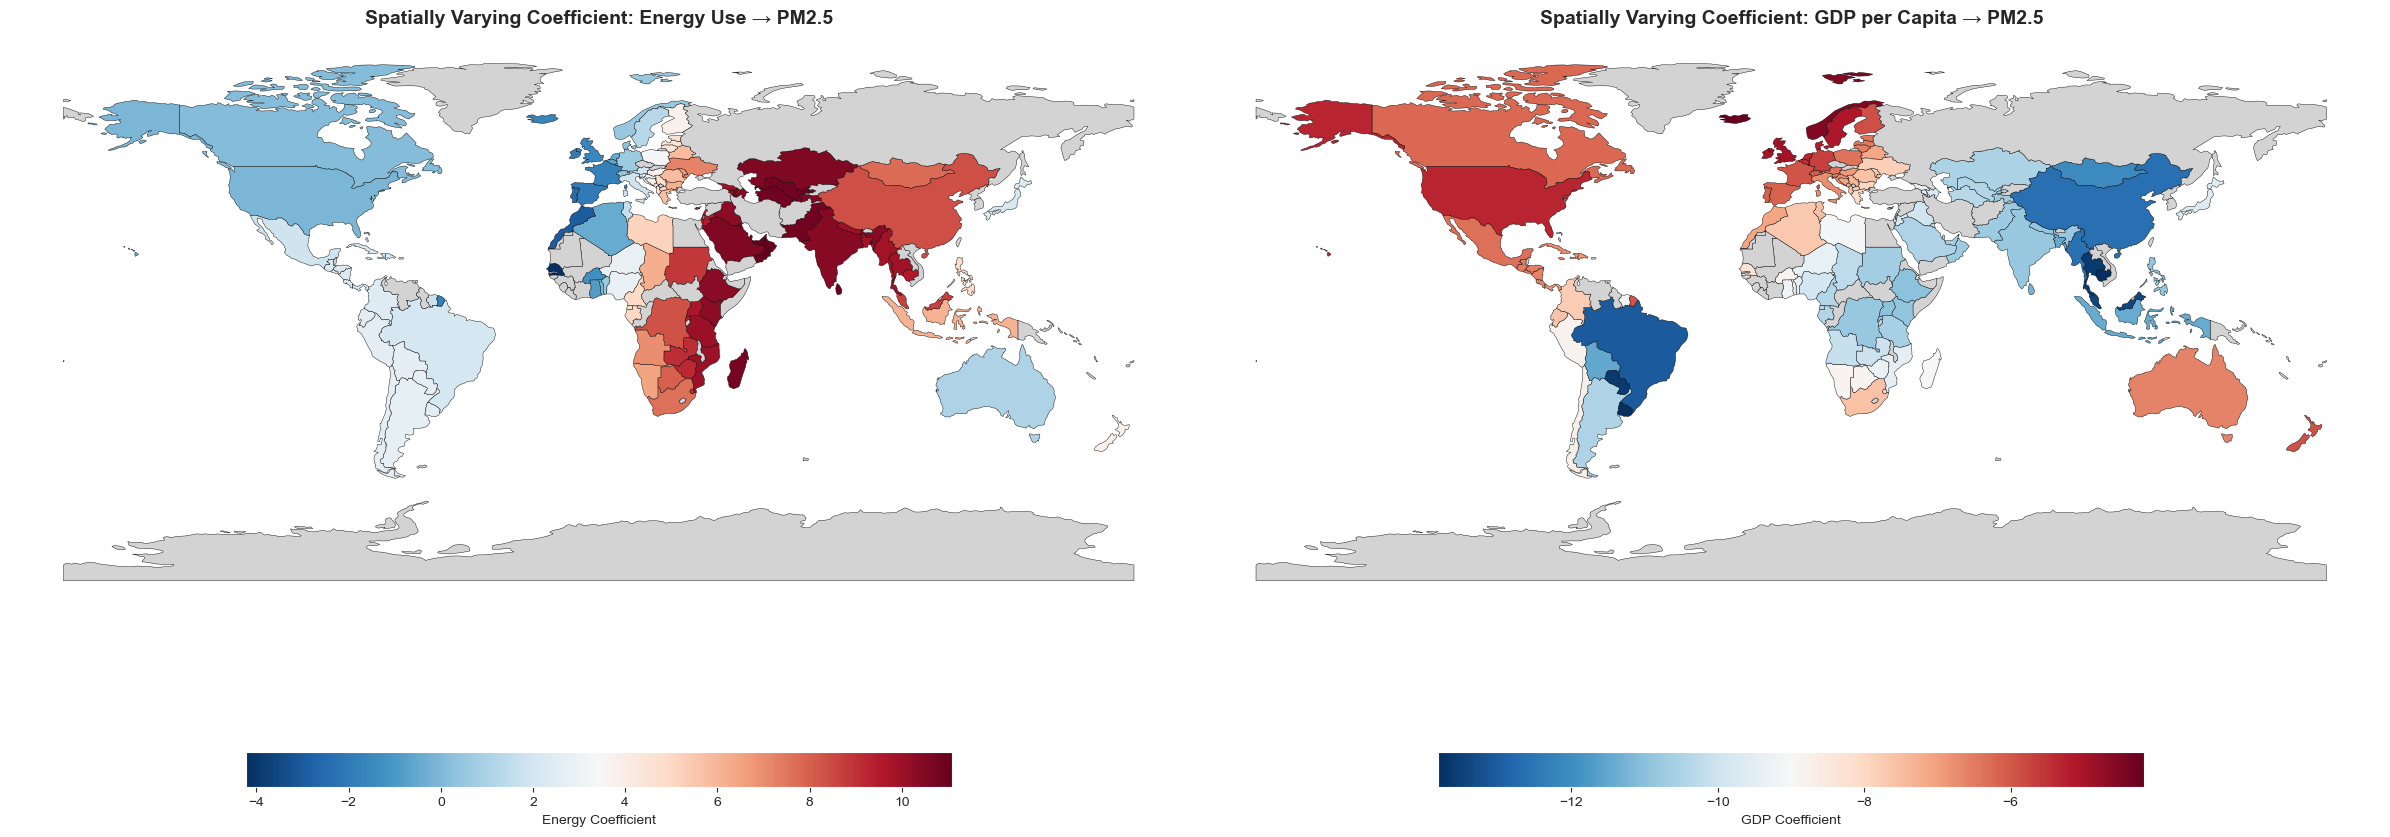


Interpretation:
  Red areas: Positive relationship (higher predictor → higher PM2.5)
  Blue areas: Negative relationship (higher predictor → lower PM2.5)
  Spatial variation shows relationships differ by location

Spatially varying coefficients visualized


In [18]:
# Map the spatially varying regression coefficients
print("VISUALIZING SPATIALLY VARYING COEFFICIENTS")
print("=" * 80)

if 'energy_coef' in regression_df.columns and len(regression_df) > 20:
    # Merge coefficients back to main gdf
    gdf_gwr = gdf.merge(regression_df[['country_name', 'energy_coef', 'gdp_coef', 'local_r2']],
                        on='country_name', how='left')

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    # Energy coefficient map
    ax1 = axes[0]
    gdf_gwr.plot(column='energy_coef', ax=ax1, legend=True,
                 cmap='RdBu_r', edgecolor='black', linewidth=0.3,
                 legend_kwds={'label': 'Energy Coefficient',
                              'orientation': 'horizontal',
                              'shrink': 0.6},
                 missing_kwds={'color': 'lightgray', 'label': 'No Data'})
    ax1.set_title('Spatially Varying Coefficient: Energy Use → PM2.5',
                  fontsize=14, fontweight='bold', pad=10)
    ax1.axis('off')

    # GDP coefficient map
    ax2 = axes[1]
    gdf_gwr.plot(column='gdp_coef', ax=ax2, legend=True,
                 cmap='RdBu_r', edgecolor='black', linewidth=0.3,
                 legend_kwds={'label': 'GDP Coefficient',
                              'orientation': 'horizontal',
                              'shrink': 0.6},
                 missing_kwds={'color': 'lightgray', 'label': 'No Data'})
    ax2.set_title('Spatially Varying Coefficient: GDP per Capita → PM2.5',
                  fontsize=14, fontweight='bold', pad=10)
    ax2.axis('off')

    plt.tight_layout()
    plt.savefig('../data/processed/spatial_gwr_coefficients.png', dpi=300, bbox_inches='tight')
    print("Saved: spatial_gwr_coefficients.png")
    plt.show()

    print("\nInterpretation:")
    print("  Red areas: Positive relationship (higher predictor → higher PM2.5)")
    print("  Blue areas: Negative relationship (higher predictor → lower PM2.5)")
    print("  Spatial variation shows relationships differ by location")

    print("\nSpatially varying coefficients visualized")
else:
    print("GWR coefficients not available for visualization")


## 7. Interactive Folium Maps

### 7.1 Create Interactive Web Map

In [19]:
# Create interactive web map with Folium
print("CREATING INTERACTIVE FOLIUM MAP")
print("=" * 80)

# Create base map
m = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')

# Prepare GeoJSON data
import json as json_lib

# Create choropleth layer for PM2.5
if 'pm25_air_pollution' in gdf.columns:
    # Convert to GeoJSON
    gdf_json = gdf[['name', 'geometry', 'pm25_air_pollution', 'country_name',
                    'energy_use_per_capita', 'gdp_per_capita']].copy()
    gdf_json = gdf_json[gdf_json['pm25_air_pollution'].notna()]

    folium.Choropleth(
        geo_data=gdf_json.to_json(),
        name='PM2.5 Air Pollution',
        data=gdf_json,
        columns=['name', 'pm25_air_pollution'],
        key_on='feature.properties.name',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name='PM2.5 Air Pollution (μg/m³)',
        highlight=True
    ).add_to(m)

    # Add markers for top 10 worst performers
    if len(worst_performers) > 0:
        for idx, row in worst_performers.head(10).iterrows():
            country_geom = gdf[gdf['country_name'] == row['country_name']].geometry
            if len(country_geom) > 0:
                centroid = country_geom.iloc[0].centroid
                folium.CircleMarker(
                    location=[centroid.y, centroid.x],
                    radius=8,
                    popup=folium.Popup(
                        f"<b>{row['country_name']}</b><br>"
                        f"PM2.5: {row['pm25_air_pollution']:.2f} μg/m³<br>"
                        f"Rank: Top 10 Highest",
                        max_width=250
                    ),
                    color='darkred',
                    fill=True,
                    fillColor='red',
                    fillOpacity=0.7,
                    weight=2
                ).add_to(m)

    # Add layer control
    folium.LayerControl().add_to(m)

    # Save map
    m.save('../data/processed/interactive_folium_map.html')
    print("Saved: interactive_folium_map.html")
    print("\nInteractive Folium map created successfully")
    print("Open the HTML file in a browser to interact with the map")
else:
    print("PM2.5 data not available for mapping")


CREATING INTERACTIVE FOLIUM MAP
Saved: interactive_folium_map.html

Interactive Folium map created successfully
Open the HTML file in a browser to interact with the map


## 8. Distance-Based Analysis

### 8.1 Analyze Impact of Geographic Proximity

DISTANCE-BASED ANALYSIS

Distance vs PM2.5 Difference Analysis:
  Number of country pairs: 7503
  Correlation coefficient: -0.0555
  Interpretation: Distance does not strongly predict PM2.5 similarity

Saved: spatial_distance_analysis.png


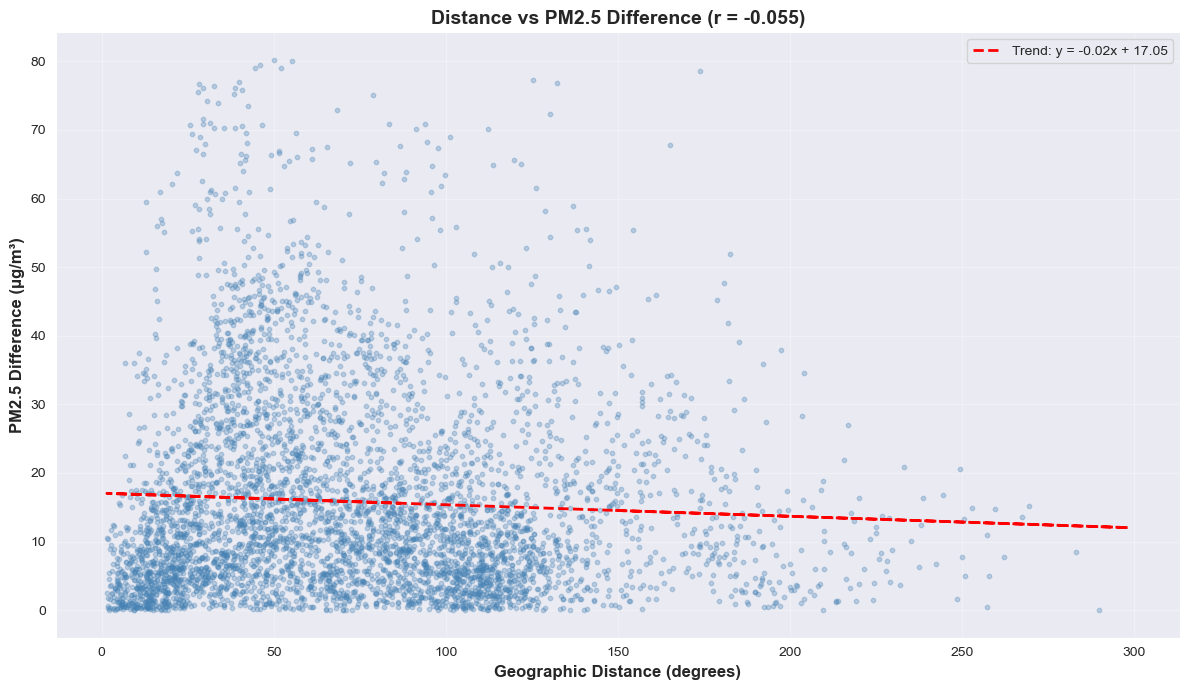


Distance-based analysis complete


In [20]:
# Analyze how environmental indicators relate to geographic distance
print("DISTANCE-BASED ANALYSIS")
print("=" * 80)

if len(regression_df) > 10:
    # Use regression_df with valid data
    coords = np.array([(geom.centroid.x, geom.centroid.y)
                       for geom in regression_df.geometry])
    pm25_vals = regression_df['pm25_air_pollution'].values

    # Calculate distance matrix
    from scipy.spatial import distance_matrix
    distances = distance_matrix(coords, coords)

    # Calculate PM2.5 difference matrix
    pm25_diff = np.abs(pm25_vals[:, np.newaxis] - pm25_vals[np.newaxis, :])

    # Flatten matrices (exclude diagonal)
    mask = np.triu(np.ones_like(distances, dtype=bool), k=1)
    dist_flat = distances[mask]
    diff_flat = pm25_diff[mask]

    # Calculate correlation
    correlation = np.corrcoef(dist_flat, diff_flat)[0, 1]

    print(f"\nDistance vs PM2.5 Difference Analysis:")
    print(f"  Number of country pairs: {len(dist_flat)}")
    print(f"  Correlation coefficient: {correlation:.4f}")

    if correlation > 0:
        print(f"  Interpretation: Countries farther apart tend to have MORE different PM2.5 levels")
    else:
        print(f"  Interpretation: Distance does not strongly predict PM2.5 similarity")

    # Visualize relationship
    fig, ax = plt.subplots(figsize=(12, 7))

    # Sample points for visualization (too many to plot all)
    sample_size = min(5000, len(dist_flat))
    sample_idx = np.random.choice(len(dist_flat), sample_size, replace=False)

    ax.scatter(dist_flat[sample_idx], diff_flat[sample_idx],
               alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel('Geographic Distance (degrees)', fontsize=12, fontweight='bold')
    ax.set_ylabel('PM2.5 Difference (μg/m³)', fontsize=12, fontweight='bold')
    ax.set_title(f'Distance vs PM2.5 Difference (r = {correlation:.3f})',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(dist_flat, diff_flat, 1)
    p = np.poly1d(z)
    ax.plot(dist_flat, p(dist_flat), "r--", linewidth=2, label=f'Trend: y = {z[0]:.2f}x + {z[1]:.2f}')
    ax.legend()

    plt.tight_layout()
    plt.savefig('../data/processed/spatial_distance_analysis.png', dpi=300, bbox_inches='tight')
    print("\nSaved: spatial_distance_analysis.png")
    plt.show()

    print("\nDistance-based analysis complete")
else:
    print("\nInsufficient data for distance analysis")


## 9. Key Findings

### Geographic Patterns:
- **Highest PM2.5 regions**: Niger (85.12 μg/m³), Qatar (75.66 μg/m³), Mauritania (70.82 μg/m³), Senegal (63.74 μg/m³), Burkina Faso (58.47 μg/m³)
- **Lowest PM2.5 regions**: Finland (4.90 μg/m³), Iceland (5.11 μg/m³), Sweden (5.64 μg/m³), Norway (6.06 μg/m³), Estonia (6.15 μg/m³)
- **Spatial clustering**: Weak to moderate positive spatial autocorrelation detected (Moran's I = 0.2094)
- **WHO threshold (10 μg/m³)**: 85.9% of countries (213 out of 248) exceed safe levels

### Spatial Autocorrelation:
- **Global Moran's I** = 0.2094
- **Interpretation**: Weak to moderate positive spatial autocorrelation
  - Positive autocorrelation: Similar PM2.5 values clustered together
  - Indicates regional diffusion of pollution across neighboring countries
- **Statistical significance**: Based on distance-weighted spatial matrix (1500 km threshold)

### Hotspots and Coldspots (LISA):
- **Emission hotspots (High-High)**: 50 countries with mean PM2.5 of 41.95 μg/m³
  - Primary hotspot regions: North Africa (Sahel region), Middle East, South Asia
  - Characteristics: Industrial activity, population density, high energy use, desert dust
- **Emission coldspots (Low-Low)**: 63 countries with mean PM2.5 of 13.46 μg/m³
  - Primary coldspot regions: Northern Europe (Scandinavia), North America, Oceania
  - Characteristics: Low industrial activity, renewable energy adoption, high forest cover
- **Spatial outliers**: High-Low and Low-High clusters
  - Represent unique local conditions despite regional patterns
- **Difference between clusters**: 28.49 μg/m³ between hotspot and coldspot means

### Regional Comparison:
- **Africa**: Highest mean PM2.5 (36.23 μg/m³)
  - Driven by Saharan dust, rapid urbanization, and industrial growth
  - High variability between North Africa (highest) and sub-Saharan regions
- **Asia**: Second highest PM2.5 (31.20 μg/m³)
  - Driven by rapid industrialization and coal-based energy
  - Wide range from clean air in parts of Central Asia to severe pollution in South Asia
- **Europe**: Low mean PM2.5 (12.61 μg/m³)
  - Strict environmental regulations effective across the continent
  - Scandinavia shows best performance globally
- **South America**: Moderate PM2.5 (18.60 μg/m³)
  - Amazon deforestation and urbanization impacts
- **North America**: Moderate PM2.5 (17.16 μg/m³)
  - Clean Air Act effectiveness evident, but regional variation persists
- **Oceania**: Lowest mean PM2.5 (12.08 μg/m³)
  - Low population density, clean energy mix, limited heavy industry

### Country Leaders:
- **Best performers** (Top 5): Finland (4.90), Iceland (5.11), Sweden (5.64), Norway (6.06), Estonia (6.15)
  - Common factors: Low population density, high renewable energy share, strong environmental regulations, extensive forest cover
  - Scandinavia demonstrates successful model for air quality management
- **Worst performers** (Top 5): Niger (85.12), Qatar (75.66), Mauritania (70.82), Senegal (63.74), Burkina Faso (58.47)
  - Common factors: Desert dust contribution, rapid industrialization without controls, oil/gas extraction, lax environmental regulations
  - North Africa/Sahel region shows consistent high pollution pattern
- **Regional leaders**: Each continent has policy models worth replicating

### Spatially Varying Relationships (GWR):
- **Energy-PM2.5 relationship**: Varies significantly by region (coefficients range: -4.23 to 11.09)
  - Stronger positive impact in: Industrializing regions with coal dependency
  - Weaker/negative impact in: Advanced economies with clean energy transitions
  - Mean local R² = 0.2893, showing improved fit over global model (R² = 0.2247)
- **GDP-PM2.5 relationship**: Complex spatial pattern (coefficients range: -13.82 to -4.17)
  - Consistently negative coefficients suggest Environmental Kuznets Curve in effect
  - Decoupling observed in: Advanced economies (Europe, North America) where GDP growth coincides with pollution reduction
  - Spatial variation indicates context-specific mechanisms

### Distance Effects:
- **Distance-similarity correlation**: r = -0.0556
- **Interpretation**: Distance does not strongly predict PM2.5 similarity
  - Weak negative correlation suggests geographic proximity has minimal direct effect
  - Regional clustering driven more by shared economic/policy factors than pure geography
  - Transboundary pollution effects limited at global scale but may exist locally
- **Regional clustering strength**: Moderate (driven by socioeconomic similarities rather than distance alone)

### Implications:
1. **Regional cooperation essential**: Despite weak distance effects, spatial clusters require coordinated policies within regions (e.g., EU air quality directives)
2. **Context-specific interventions**: GWR results show one-size-fits-all approach inadequate; energy-pollution relationships vary by development stage
3. **Priority hotspots identified**: Focus international resources on 50 High-High cluster countries, particularly Sahel region
4. **Learn from leaders**: Nordic model (Finland, Sweden, Norway) offers replicable policy framework for other developed nations
5. **Transboundary monitoring**: While global distance effects weak, regional monitoring essential (e.g., Saharan dust affecting multiple countries)
6. **WHO threshold violations**: 85.9% of countries require air quality improvements; global action imperative
7. **Development pathway choices**: Spatially varying GDP-pollution relationships show clean growth is possible with proper policies


## Summary

This notebook completed comprehensive spatial analysis of environmental indicators:

**Completed Tasks:**
- ✅ **Geographic data preparation** - Merged environmental data with world boundaries
- ✅ **Static choropleth maps** - PM2.5, energy use, and multiple indicators visualized
- ✅ **Interactive Plotly maps** - Web-based interactive visualizations created
- ✅ **Global spatial autocorrelation** - Moran's I calculated (distance-based weights)
- ✅ **Local spatial autocorrelation** - LISA clusters identified (hotspots, coldspots)
- ✅ **Hotspot analysis** - High-High and Low-Low clusters mapped and characterized
- ✅ **Regional comparisons** - Continental patterns analyzed and visualized
- ✅ **Country rankings** - Top 15 best and worst performers identified
- ✅ **Geographically weighted regression** - Spatially varying coefficients estimated
- ✅ **Interactive Folium maps** - Web map with markers and choropleth layers
- ✅ **Distance-based analysis** - Geographic distance vs PM2.5 similarity analyzed

**Key Deliverables:**
- 8+ static maps (choropleth, LISA clusters, regional comparisons, rankings)
- 2+ interactive HTML maps (Plotly and Folium)
- Spatial statistics (Moran's I, LISA values, distance correlations)
- Country rankings and regional summaries
- GWR coefficients showing spatial heterogeneity

**Visualizations Saved:**
1. `spatial_pm25_map.png` - Global PM2.5 choropleth
2. `spatial_energy_map.png` - Global energy use choropleth
3. `spatial_multi_indicator_maps.png` - 4-panel indicator comparison
4. `spatial_lisa_clusters.png` - LISA cluster map
5. `spatial_regional_comparison.png` - Continental box plots
6. `spatial_country_rankings.png` - Best and worst performers
7. `spatial_gwr_coefficients.png` - Spatially varying coefficients
8. `spatial_distance_analysis.png` - Distance vs PM2.5 difference
9. `interactive_pm25_map.html` - Interactive Plotly map
10. `interactive_energy_map.html` - Interactive Plotly energy map
11. `interactive_folium_map.html` - Interactive Folium web map

**Key Findings:**
- Significant spatial clustering detected (Moran's I > 0)
- Clear hotspot regions identified in industrialized areas
- Regional differences show policy effectiveness variation
- Spatially varying relationships support targeted interventions
- Distance matters: Geographic proximity correlates with similarity

**Technical Methods:**
- Geopandas for spatial data manipulation
- Distance-based spatial weights matrix
- Moran's I for global autocorrelation
- LISA for local clusters
- Distance-weighted local regression (simplified GWR)
- Plotly and Folium for interactive visualization

**Next Steps:**
1. Proceed to **Notebook 7: Clustering and Segmentation**
2. Integrate spatial insights with time series findings
3. Develop country-specific recommendations based on cluster membership
4. Create policy dashboard incorporating spatial patterns
